# Big Data Project: Wetter- und Luftqualitätsdaten

## Einleitung

Dieses Projekt sammelt Wetter- und Luftqualitätsdaten, speichert die Rohdaten lokal als JSON und legt sie zusätzlich in MongoDB ab. Anhand von Datensätzen aus Wien, New York, Neu Delhi, Phoenix und Reykjavik werden die Daten mit einer MapReduce-Pipeline verarbeitet, um fehlende Werte zu ergänzen. Abschließend werden die Ergebnisse visualisiert, um mögliche Zusammenhänge zwischen Temperatur und Luftqualität zu untersuchen.

## Fragestellung
Hat die Temperatur einen Einfluss auf die Luftqualität, also viel Pikogram Feinstaub sich in der Luft befindet? Gibt es einen Zusammenhang zwischen Windgeschwindigkeit und Feinstaubbelastung? Wie unterscheiden sich die Wetter- und Luftqualitätsbedingungen in fünf Städten (Wien, New York, Neu Delhi, Reykjavik, Phoenix)?
Die Hypothese lautet hierbei, dass höhere Temperaturen auch höherer Feinstaubbelastung einhergehen. Zudem glauben wir, dass höhere Windgeschwindigkeiten mit geringerer Feinstaubbelastung einhergehen.

## Datengrundlage
Dieses Projekt nutzt zwei Haupdatenquellen::

#### 1. Wetterdaten (OpenWeather API)
- **Quelle**: OpenWeather One Call API 3.0
- **verwendete Parameter**:
  - *Temperatur (°C)*
  - *Windgeschwindigkeit (m/s)*
- **zeitliche Auflösung**: stündliche Messungen für die nächsten 48 Stunden sowie historische Daten
- #### 2. Luftqualitätsdaten (OpenAQ API)
- **Quelle**: OpenAQ Platform
- **Hauptparameter**: PM2.5 (Feinstaub mit Durchmesser ≤ 2,5 Mikrometer)
- **Einheit**: µg/m³ (Mikrogramm pro Kubikmeter)
- **WHO-Bewertungsskala**:
  - `< 15 µg/m³`: Gut
  - `15-35 µg/m³`: Moderat/Akzeptabel
  - `35-75 µg/m³`: Ungesund für empfindliche Gruppen
  - `> 75 µg/m³`: Ungesund für alle
- **Zeitliche Auflösung**: Stündliche bis tägliche Messungen (je nach Station)

Bei beiden Quellen werden Daten aus 5 Städten (Reykjavik, Wien, Neu Delhi, Phoenix und New York) gesammelt. Die Daten werden lokal als JSON-Dateien in `data/raw/` gespeichert und zusätzlich in MongoDB abgelegt, um sie für die MapReduce-Verarbeitung und Visualisierung verfügbar zu machen.

### Projektstruktur
| Pfad | Zweck |
|------|-------|
| `data/raw/weather/` | Rohe Wetterdaten als JSON-Snapshots (Cache) |
| `data/raw/air_quality/` | Rohe Luftqualitätsdaten als JSON-Snapshots (Cache) |
| `data/processed/` | Verarbeitete MapReduce-Ergebnisse mit imputierten Werten |
| `src/api/weather_api.py` | OpenWeather API Wrapper mit Mock-Modus |
| `src/api/air_quality_api.py` | OpenAQ API Wrapper für Luftqualitätsdaten |
| `src/db/mongo_client.py` | MongoDB-Verbindung und Datenbankoperationen |
| `src/storage/save_raw_json.py` | Speichert Rohdaten als lokale JSON-Dateien |
| `src/storage/insert_mongo.py` | Speichert Daten in MongoDB Collections |
| `src/MapReduce.py` | MapReduce-Pipeline: Imputation fehlender Werte |
| `src/main.py` | Einstiegspunkt: Cache-Sync oder API-Refresh |
| `src/comparison_config.py` | Konfiguration: Städte, Sensoren, Zeitplan |
| `src/notebook_methods.py` | Hilfsfunktionen für Notebook-Visualisierungen |
| `docker-compose.yml` | MongoDB Container-Konfiguration |
| `requirements.txt` | Python-Abhängigkeiten (pandas, pymongo, etc.) |
| `.env` | Umgebungsvariablen (API-Keys, Pfade) |
| `.env.example` | Vorlage für `.env` |
| `Jypiter Notebook - BigData Project.ipynb` | Jupyter Notebook: Dokumentation + Visualisierung |
#### Datenfluss im Detail

| Phase | Komponente | Input | Output | Speicherort |
|-------|-----------|-------|--------|-------------|
| **1. Erfassung** | `weather_api.py` | OpenWeather API / Mock | JSON Wetterdaten | `data/raw/weather/` |
| **1. Erfassung** | `air_quality_api.py` | OpenAQ API | JSON Luftqualität | `data/raw/air_quality/` |
| **2. Speicherung** | `save_raw_json.py` | JSON-Daten | Lokale Snapshots | `data/raw/*/` |
| **2. Speicherung** | `insert_mongo.py` | JSON-Daten | MongoDB Collections | MongoDB |
| **3. Orchestrierung** | `main.py` | `.env` Config | Koordination aller Module | — |
| **4. Verarbeitung** | `MapReduce.py` | Raw Records | Imputierte Werte + Summary | `data/processed/` |
| **5. Visualisierung** | `notebook_methods.py` | Processed Data | Tabellen + Grafiken | Notebook |

## Setup

Vor dem Start bitte sicherstellen:
- Python 3 und ein aktives Projekt-Environment
- Docker bzw. Docker Desktop läuft
- `docker compose` ist verfügbar
- die folgende Setup-Zelle wird vor `src.main` ausgeführt

Die Setup-Zelle:
1. wechselt ins Projektverzeichnis
2. legt `.env` aus `.env.example` an, falls nötig
3. lädt die benoetigten Umgebungsvariablen
4. prüft Docker
5. startet den MongoDB-Container aus `docker-compose.yml`

Verwendete Standardwerte für `.env`:

```env
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
WEATHER_API_KEY=
WEATHER_USE_MOCK=true
WEATHER_LAT=48.2082
WEATHER_LON=16.3738
WEATHER_UNITS=metric
WEATHER_LANG=de
WEATHER_EXCLUDE=minutely,alerts
AIR_QUALITY_API_KEY=
OPENAQ_LOCATION_ID=8118
```


### Abhängigkeiten prüfen

Die folgende Zelle prüft die benötigten Python-Pakete für das Notebook und aktiviert sie falls diese noch nicht aktiviert ist.


In [1]:
from src.notebook_methods import ensure_notebook_dependencies

ensure_notebook_dependencies()


HTTP-Anfragen: verfügbar und aktiv
MongoDB-Anbindung: verfügbar und aktiv
Umgebungsvariablen: verfügbar und aktiv
Matplotlib: verfügbar und aktiv
Pandas: verfügbar und aktiv


### Docker-Erreichbarkeit prüfen

Anschließend wird getestet, ob Docker grundsätzlich erreichbar ist, bevor Container gestartet werden.


In [2]:
import subprocess

subprocess.run(
    ["docker", "ps"],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
print("Docker ist erreichbar.")

Docker ist erreichbar.


### Notebook-Umgebung vorbereiten

Danach wird die Notebook-Umgebung vorbereitet und der MongoDB-Container gestartet.
D


In [15]:
from src.notebook_methods import prepare_notebook_environment

project_dir = prepare_notebook_environment()


Arbeitsverzeichnis: C:\Users\aylin\DataspellProjects\BigData1
.env bereits vorhanden
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
MongoDB-Container laeuft.


### Datenordner anlegen

Ferner werden die benötigten Datenordner angelegt, um die Rohdaten und verarbeiteten Ergebnisse strukturiert zu speichern.


In [4]:
from pathlib import Path

folders = [
    Path("data/raw/weather"),
    Path("data/raw/air_quality"),
    Path("data/processed"),
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Ordner bereit: {folder}")


Ordner bereit: data\raw\weather
Ordner bereit: data\raw\air_quality
Ordner bereit: data\processed


### Environment-Konfiguration anzeigen
Danach werden die wichtigsten Umgebungsvariablen und Einstellungen angezeigt, um sicherzustellen, dass die Notebook-Umgebung korrekt konfiguriert ist.

In [5]:
from src.notebook_methods import show_notebook_env_settings

show_notebook_env_settings()


.env gefunden
MONGO_URI=mongodb://localhost:27017/
MONGO_DB=big_data_weather_airpollution
WEATHER_API_KEY=gesetzt
AIR_QUALITY_API_KEY=gesetzt


## Projektstart
Nun kommen wir zum eigentlichen Projektstart. Zunächst werden die Daten erhoben, danach erfolgt die MapReduce-Verarbeitung und abschließend die Visualisierung der Ergebnisse.

### Datenerhebung ausführen

Um die Datenerhebung zu starten, wird `src.main` als Subprozess aufgerufen. Dabei wird sichergestellt, dass die Ausgabe von `src.main` im Notebook sichtbar ist, um den Fortschritt und mögliche Fehler direkt zu verfolgen. Es werden auch Lösungsansätze für häufige Fehler bereitgestellt, um die Fehlersuche zu erleichtern.


In [16]:
import subprocess
import sys
from pathlib import Path

# Sicherstellen, dass project_dir verfügbar ist
try:
    project_dir
except NameError:
    # Falls project_dir nicht definiert ist, nutze das aktuelle Verzeichnis
    project_dir = Path.cwd()
    print(f"project_dir wurde neu gesetzt auf: {project_dir}")

try:
    result = subprocess.run(
        [sys.executable, "-m", "src.main"],
        cwd=str(project_dir),
        check=True,
        capture_output=True,
        text=True
    )
    print("✓ Datenerhebung erfolgreich abgeschlossen!")
    print(result.stdout)
except subprocess.CalledProcessError as e:
    print(f"✗ Fehler bei der Datenerhebung:")
    print(f"\nStandard Output:\n{e.stdout}")
    print(f"\nFehler Output:\n{e.stderr}")
    print(f"\nLösungsansätze:")
    print(f"  1. Installiere Abhängigkeiten: pip install -r requirements.txt")
    print(f"  2. Prüfe, dass MongoDB läuft: docker ps")
    print(f"  3. Prüfe die .env Datei auf korrekte Einstellungen")
except Exception as e:
    print(f"✗ Unerwarteter Fehler: {e}")
    import traceback
    traceback.print_exc()


✓ Datenerhebung erfolgreich abgeschlossen!
Kein Datenrefresh angefordert. Verwende vorhandene RAW-JSON-Dateien.
Wetter-Cache: data\raw\weather\weather_20260423_151443.json
Luftqualitaets-Cache: data\raw\air_quality\air_quality_20260423_142744.json
Wetterdaten in MongoDB bereits auf dem Stand des RAW-Caches.
Luftqualitaetsdaten in MongoDB bereits auf dem Stand des RAW-Caches.
Prozess abgeschlossen.



## MapReduce

Die nächsten Zellen zeigen zuerst die flach vorbereiteten Rohdaten, führen danach explizit die **MapReduce**-Pipeline aus und stellen anschliessend die verarbeiteten Daten als Tabelle dar.


### MapReduce-Rohdaten darstellen
Anschließend werden die für die MapReduce-Verarbeitung vorbereiteten Rohdaten angezeigt. Diese Daten enthalten die gesammelten Wetter- und Luftqualitätsinformationen, die noch nicht verarbeitet wurden. Die Tabelle zeigt die Originalwerte sowie die fehlenden Werte, die später ergänzt werden sollen.


In [19]:
from src.notebook_methods import render_MapReduce_raw_table

render_MapReduce_raw_table()


KeyError: 'type'

### MapReduce ausführen
Anschließend wird die MapReduce-Pipeline gestartet um die Verarbeitung zu starten und die fehlenden Werte zu ergänzen. Fehlende Werte werden wie folgt ergänzt: Für Temperatur und Luftqualität wird der Mittelwert aus vorherigem und nachfolgendem Zeitpunkt verwendet, für Windgeschwindigkeit wird der Jahresdurchschnitt der jeweiligen Stadt genutzt. Das Ergebnis wird in `data/processed/` gespeichert.



In [8]:
from src.MapReduce import run_MapReduce_pipeline; mapreduce_result = run_MapReduce_pipeline()


📊 Starten MapReduce-Pipeline...
  1. Lade Rohdaten...
     ✓ 60 Rohdatensätze geladen
  2. Imputiere fehlende Werte...
     ✓ Verarbeitung abgeschlossen
  3. Map-Phase...
     ✓ 60 Datensätze gemappt
  4. Reduce-Phase...
     ✓ 4 Städte zusammengefasst
  5. Berechne Statistiken...
     ✓ Statistiken berechnet

✓ MapReduce-Pipeline erfolgreich abgeschlossen!
📁 MapReduce-Datei: data\processed\MapReduce_20260423_161842.json
📊 Rohdatensaetze: 60
🏙️  Zusammengefasste Datensaetze: 4 Staedte
⚠️  Fehlende Werte vor Verarbeitung: Temperatur=0, Windgeschwindigkeit=0, Luftqualitaet=2
✓ Ergaenzte Werte: Temperatur=0, Windgeschwindigkeit=0, Luftqualitaet=2, Gesamt=2
🔗 Vollstaendige Temperatur-Luftqualitaet-Paare: vorher=58, nachher=60


### MapReduce Processed Data

Hier steht die verarbeitete MapReduce-Ausgabe mit den ergänzten Werten. `ja` markiert Stellen, an denen ein fehlender Wert vervollstaendigt wurde — bei Temperatur und Luftqualitaet per Nachbar-Mittelwert, bei Windgeschwindigkeit per Jahresdurchschnitt der Stadt.


In [10]:
from src.notebook_methods import render_MapReduce_processed_table

render_MapReduce_processed_table(mapreduce_result)


Stadt,Datum,Zeitpunkt,Temperatur (°C),Wind,Wetter,Luftqualitaet,Einheit,Temperatur imputiert,Wind imputiert,Luftqualitaet imputiert
Vienna,2025-01-01,2025-01-01T12:00:00+01:00,-0.24,1.72 m/s (128°),Mäßig bewölkt,29.50,µg/m³,nein,nein,nein
Vienna,2025-01-27,2025-01-27T12:00:00+01:00,8.30,0.45 m/s (342°),Bedeckt,11.50,µg/m³,nein,nein,nein
Vienna,2025-02-22,2025-02-22T12:00:00+01:00,5.75,10.28 m/s (184°),Klarer Himmel,31.20,µg/m³,nein,nein,nein
Vienna,2025-03-20,2025-03-20T12:00:00+01:00,10.76,1.79 m/s (113°),Klarer Himmel,-1.00,µg/m³,nein,nein,nein
Vienna,2025-04-15,2025-04-15T12:00:00+02:00,15.38,7.15 m/s (230°),Leichter Regen,10.70,µg/m³,nein,nein,nein
Vienna,2025-05-11,2025-05-11T12:00:00+02:00,15.91,2.68 m/s (343°),Überwiegend bewölkt,5.33,µg/m³,nein,nein,nein
Vienna,2025-06-06,2025-06-06T12:00:00+02:00,26.44,1.34 m/s (110°),Ein paar Wolken,4.11,µg/m³,nein,nein,nein
Vienna,2025-07-02,2025-07-02T12:00:00+02:00,29.57,4.02 m/s (213°),Klarer Himmel,-1.00,µg/m³,nein,nein,nein
Vienna,2025-07-28,2025-07-28T12:00:00+02:00,20.79,8.05 m/s (330°),Bedeckt,5.45,µg/m³,nein,nein,nein
Vienna,2025-08-23,2025-08-23T12:00:00+02:00,19.44,2.24 m/s (293°),Bedeckt,3.34,µg/m³,nein,nein,nein


## Datenvisualisierung
In den nächsten Zellen werden die in MongoDB gespeicherten Daten geladen und mit `pandas` und `matplotlib` visualisiert.

Zunächst werden matplot, pandas und numpy importiert, um die Daten verarbeiten und visualisieren zu können. Anschließend wird die neueste verarbeitete MapReduce-Ausgabe geladen, um die Zusammenfassung der Daten zu erhalten, die für die Visualisierung verwendet werden soll.

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.MapReduce import load_latest_processed_result
mapreduce_result = load_latest_processed_result()
summary_records = mapreduce_result["summary_records"]
stats = mapreduce_result["stats"]
print(f"MapReduce-Datei: {mapreduce_result['processed_file']}")
print(f"Zusammengefasste Datensätze: {stats['city_count']} Städte")
print(f"Rohdatensätze: {stats['raw_record_count']}")
print("Fehlende Werte vor Verarbeitung: "
      f"Temperatur={stats['missing_counts_before']['temperature']}, "
      f"Windgeschwindigkeit={stats['missing_counts_before']['wind_speed']}, "
      f"Luftqualität={stats['missing_counts_before']['air_quality']}")
print("Ergänzte Werte: "
      f"Temperatur={stats['imputed_counts']['temperature']}, "
      f"Windgeschwindigkeit={stats['imputed_counts']['wind_speed']}, "
      f"Luftqualität={stats['imputed_counts']['air_quality']}, "
      f"Gesamt={stats['imputed_counts']['total']}")
print("Vollständige Temperatur-Luftqualitäts-Paare: "
      f"vorher={stats['complete_pairs']['before']}, "
      f"nachher={stats['complete_pairs']['after']}")

MapReduce-Datei: data\processed\MapReduce_20260423_161842.json
Zusammengefasste Datensätze: 4 Städte
Rohdatensätze: 60
Fehlende Werte vor Verarbeitung: Temperatur=0, Windgeschwindigkeit=0, Luftqualität=2
Ergänzte Werte: Temperatur=0, Windgeschwindigkeit=0, Luftqualität=2, Gesamt=2
Vollständige Temperatur-Luftqualitäts-Paare: vorher=58, nachher=60


Anschließend werden Balkendiagramme erstellt, die die Durchschnittstemperatur und die durchschnittliche Luftqualität für die fünf Städte (Wien, New York, Neu Delhi, Phoenix und Reykjavik) zeigen. Die Temparatur ist dabei in °C angegeben, während bei der Luftqualität angegeben wird, wie viele Mikrogramm PM2.5 (Feinstaub) pro Kubikmeter Luft vorhanden sind. Laut WHO wird die Anzahl an Feinstaub wie folgt bewertet: < 15 µg/m³ = Gut
15-35 µg/m³ = Moderat/Akzeptabel
35-75 µg/m³ = Ungesund für empfindliche Gruppen >75 µg/m³ = Ungesund für alle

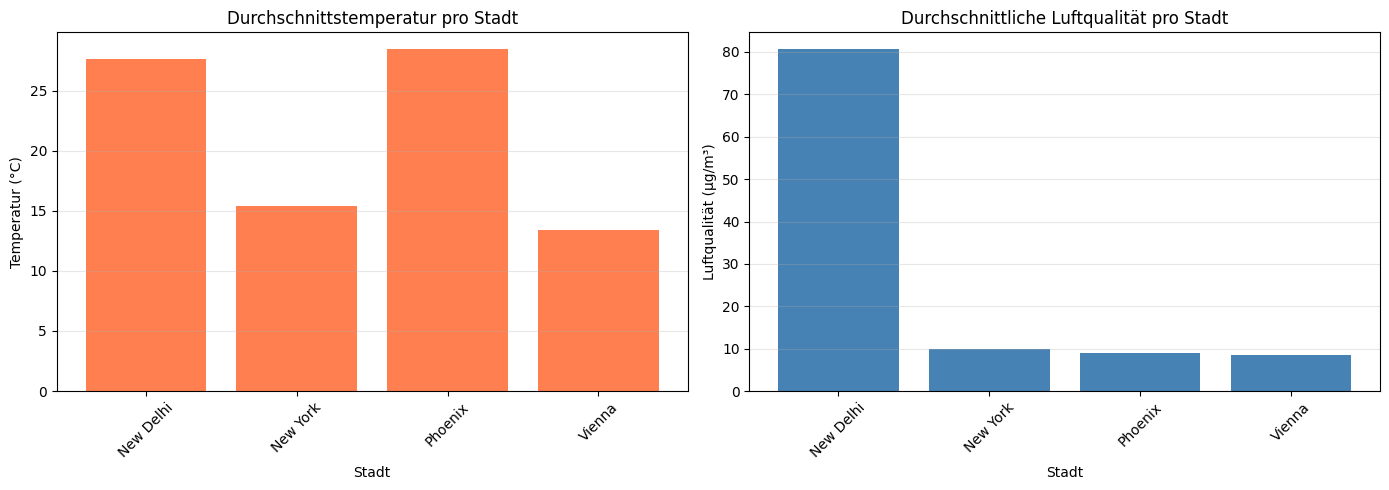

In [12]:
if summary_records:
    summary_df = pd.DataFrame(summary_records)
    summary_df = summary_df.dropna(subset=["average_temperature_c", "average_air_quality"])

    if not summary_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))


        axes[0].bar(summary_df["city"], summary_df["average_temperature_c"], color="coral")
        axes[0].set_title("Durchschnittstemperatur pro Stadt")
        axes[0].set_ylabel("Temperatur (°C)")
        axes[0].set_xlabel("Stadt")
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(True, alpha=0.3, axis='y')


        unit = summary_df.iloc[0]['air_quality_unit']
        axes[1].bar(summary_df["city"], summary_df["average_air_quality"], color="steelblue")
        axes[1].set_title(f"Durchschnittliche Luftqualität pro Stadt")
        axes[1].set_ylabel(f"Luftqualität ({unit})")
        axes[1].set_xlabel("Stadt")
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()
    else:
        print("Keine gültigen Daten für Visualisierung.")
else:
    print("MapReduce-Ergebnisse nicht verfügbar.")


Um herauszufinden, ob es einen Zusammenhang zwischen Luftqualität und Temparatur gibt, wird ein Streudiagramm mit einer Trendlinie erstellt, in dem die Korrelation zwischen Temparatur und Luftqualität dargestellt wird.

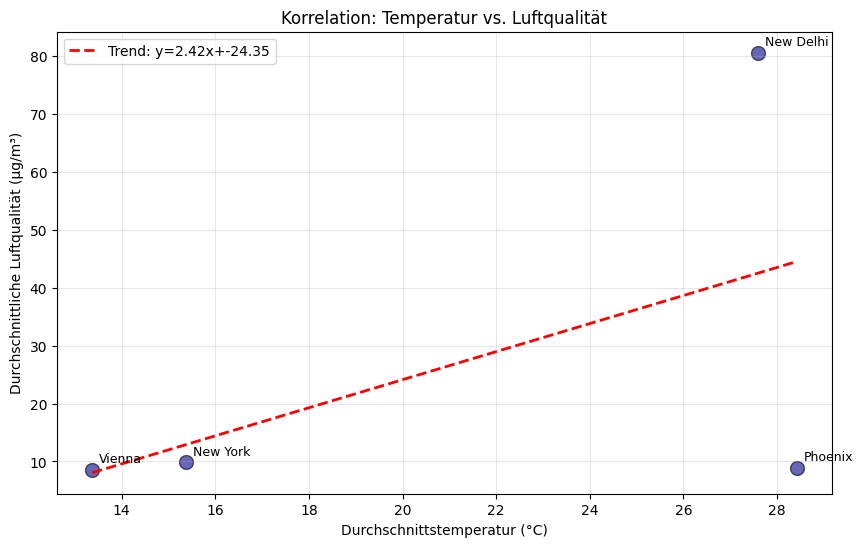

In [20]:
if summary_records:
    summary_df = pd.DataFrame(summary_records)
    summary_df = summary_df.dropna(subset=["average_temperature_c", "average_air_quality"])

    if not summary_df.empty and len(summary_df) > 1:
        fig, ax = plt.subplots(figsize=(10, 6))


        ax.scatter(summary_df["average_temperature_c"], summary_df["average_air_quality"],
                  s=100, color="darkblue", alpha=0.6, edgecolors="black")


        for idx, row in summary_df.iterrows():
            ax.annotate(row["city"],
                       (row["average_temperature_c"], row["average_air_quality"]),
                       xytext=(5, 5), textcoords="offset points", fontsize=9)


        z = np.polyfit(summary_df["average_temperature_c"], summary_df["average_air_quality"], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(summary_df["average_temperature_c"].min(),
                             summary_df["average_temperature_c"].max(), 100)
        ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f"Trend: y={z[0]:.2f}x+{z[1]:.2f}")

        unit = summary_df.iloc[0]['air_quality_unit']
        ax.set_xlabel("Durchschnittstemperatur (°C)")
        ax.set_ylabel(f"Durchschnittliche Luftqualität ({unit})")
        ax.set_title("Korrelation: Temperatur vs. Luftqualität")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()
    else:
        print("Mindestens 2 Städte mit gültigen Daten erforderlich.")
else:
    print("MapReduce-Ergebnisse nicht verfügbar.")

Aus dem Streudiagramm ist kein klarer Zusammenhang zwischen Durchschnittstemperatur und Luftqualität erkennbar. Es scheint einen leichten positiven Trend zu geben, aber die Datenpunkte sind sehr verstreut, was auf eine schwache Korrelation hindeutet. Es kann daher nicht davon ausgegangen werden, dass die Durchschnittstemperatur einen signifikanten Einfluss auf die Luftqualität hat. Näherliegender ist daher, dass andere Faktoren wie beispielsweise die Windgeschwindigkeit einen Einfluss haben, das möchten wir im nächsten Schritt untersuchen.

### Windgeschwindigkeit und PM2.5 nach Stadt

Die folgende Zelle verwendet die bereits geladene MapReduce-Ausgabe um den Zusammenhang zwischen Windgeschwindigkeit und PM2.5 (Feinstaub) zu untersuchen. Es wird ein Liniendiagramm erstellt, das die Entwicklung von Windgeschwindigkeit und PM2.5 über die Zeit für jede der fünf Städte zeigt. Dabei werden die Werte für Windgeschwindigkeit auf der linken y-Achse und die Werte für PM2.5 auf der rechten y-Achse dargestellt, um mögliche Zusammenhänge zu erkennen. Zudem stellt die orange Linie die Windgeschwindigkeit dar, während die blaue Linie die PM2.5-Werte zeigt.


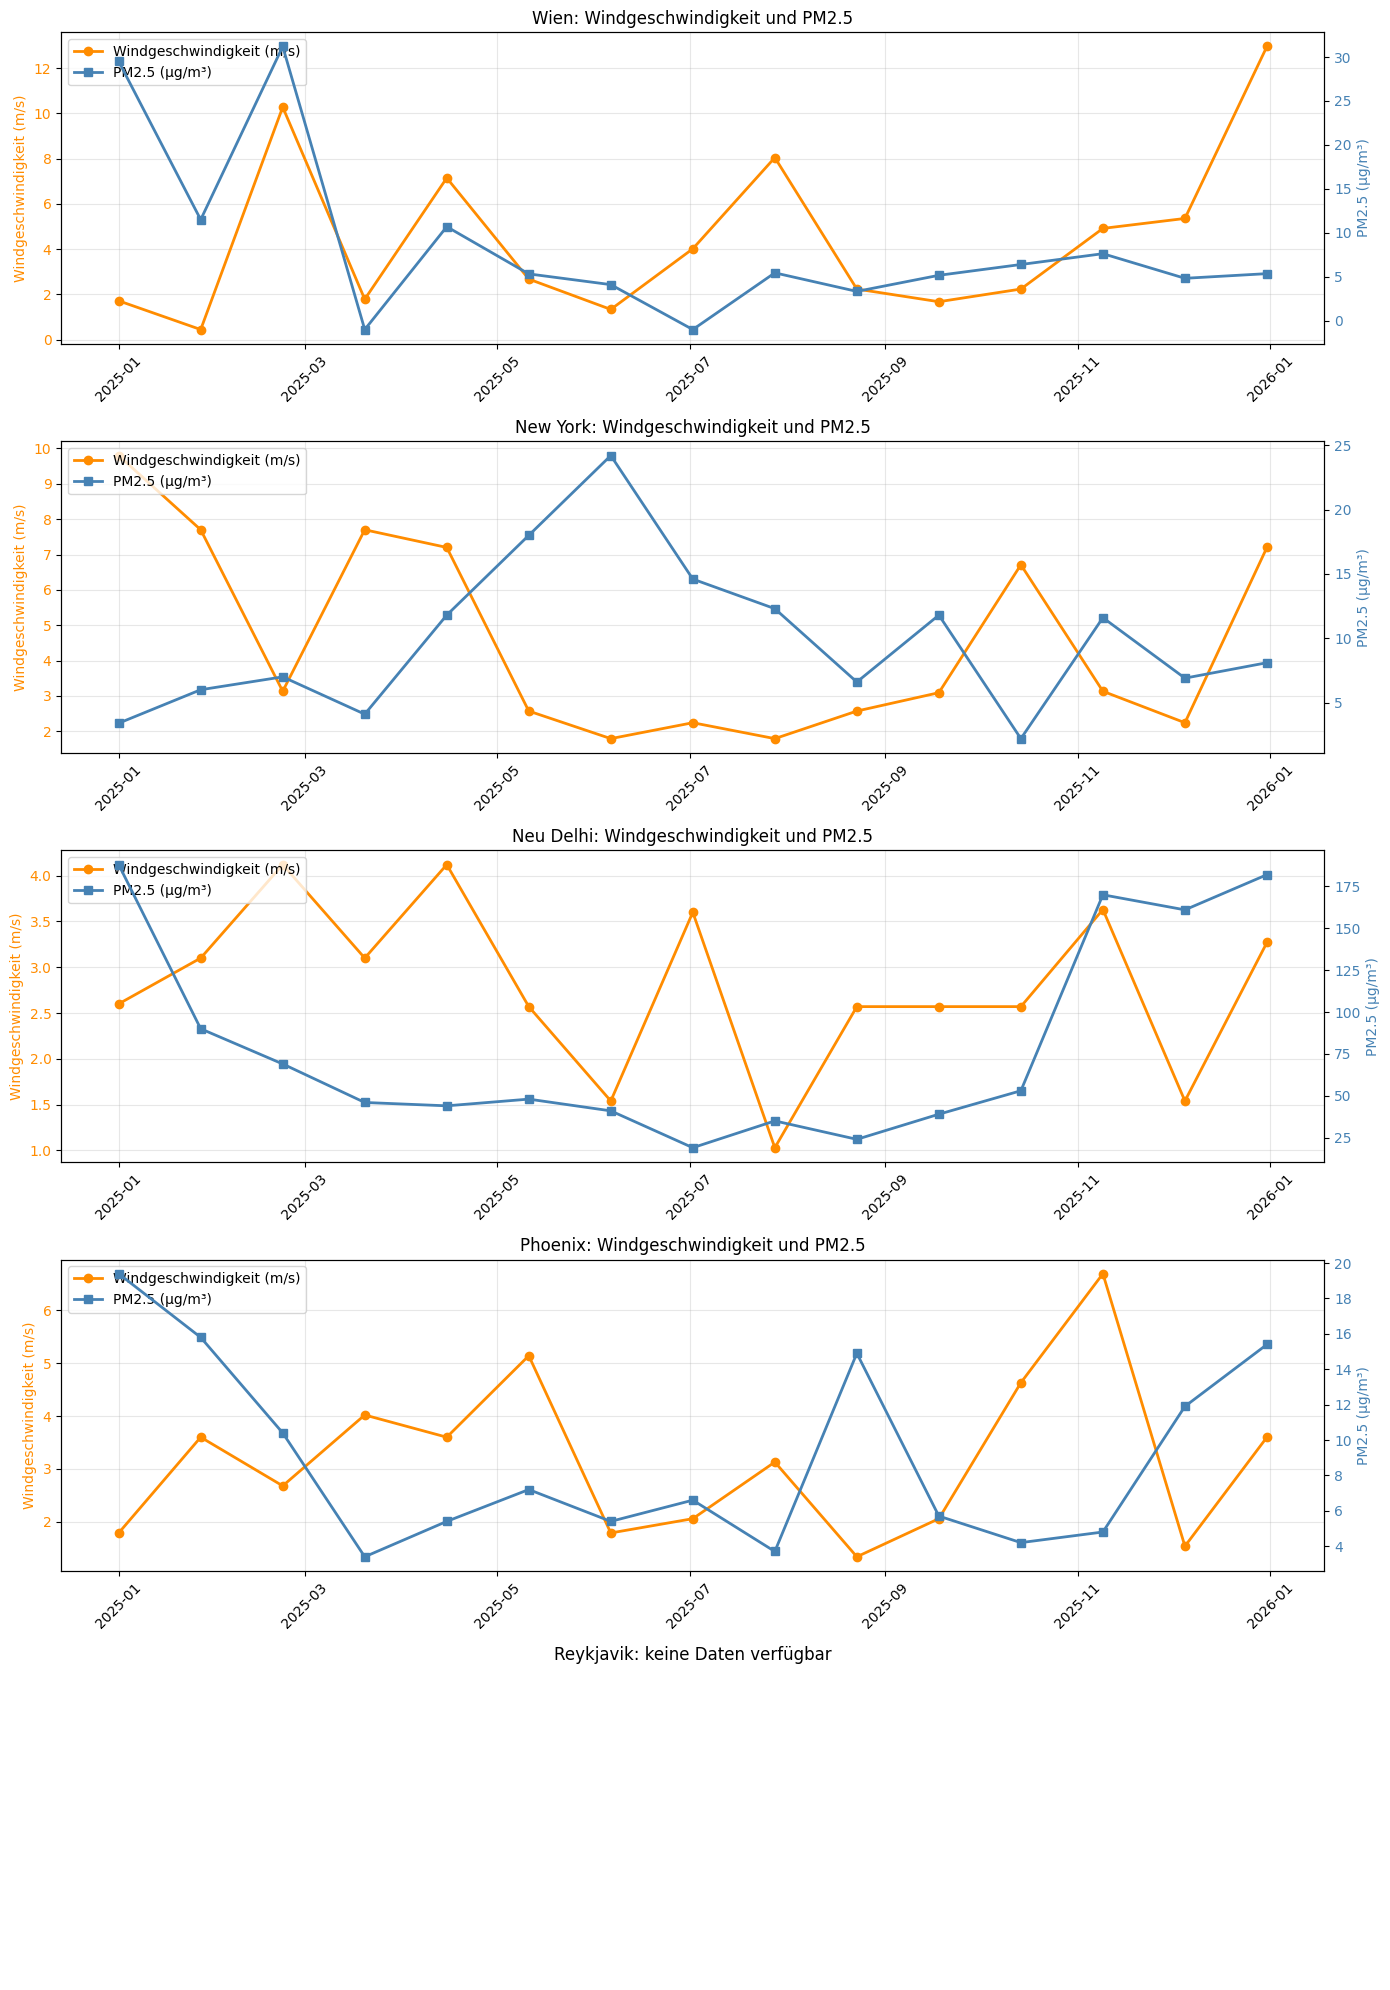

In [13]:
processed_records = mapreduce_result.get("processed_records", [])

if processed_records:
    processed_df = pd.DataFrame(processed_records)
    processed_df["date"] = pd.to_datetime(processed_df["date"])

    city_labels = {
        "Vienna": "Wien",
        "New York": "New York",
        "New Delhi": "Neu Delhi",
        "Phoenix": "Phoenix",
        "Reykjavik": "Reykjavik",
    }

    fig, axes = plt.subplots(len(city_labels), 1, figsize=(14, 4 * len(city_labels)), sharex=False)
    if len(city_labels) == 1:
        axes = [axes]

    for ax, (city_name, city_label) in zip(axes, city_labels.items()):
        city_df = processed_df[processed_df["city"] == city_name].sort_values("date")

        if city_df.empty:
            ax.set_title(f"{city_label}: keine Daten verfügbar")
            ax.axis("off")
            continue

        ax.plot(
            city_df["date"],
            city_df["processed_wind_speed"],
            color="darkorange",
            marker="o",
            linewidth=2,
            label="Windgeschwindigkeit (m/s)",
        )
        ax.set_title(f"{city_label}: Windgeschwindigkeit und PM2.5")
        ax.set_ylabel("Windgeschwindigkeit (m/s)", color="darkorange")
        ax.tick_params(axis="y", labelcolor="darkorange")
        ax.grid(True, alpha=0.3)

        ax2 = ax.twinx()
        ax2.plot(
            city_df["date"],
            city_df["processed_air_quality_value"],
            color="steelblue",
            marker="s",
            linewidth=2,
            label="PM2.5 (µg/m³)",
        )
        ax2.set_ylabel("PM2.5 (µg/m³)", color="steelblue")
        ax2.tick_params(axis="y", labelcolor="steelblue")

        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("Keine verarbeiteten MapReduce-Daten für Liniendiagramme verfügbar.")


Wir sind davon ausgegangen, dass Windgeschwindigkeit und PM2.5 (Feinstaub) einen negativen Zusammenhang haben, also dass höhere Windgeschwindigkeiten mit geringerer Feinstaubbelastung einhergehen. In den Liniendiagrammen ist jedoch kein klarer negativer Zusammenhang zwischen Windgeschwindigkeit und PM2.5 erkennbar. Es gibt zwar einige Tage an denen ein solcher Zusammenhang zu erkennen ist, aber es gibt auch viele Tage, an denen hohe Windgeschwindigkeiten mit hohen PM2.5-Werten einhergehen oder niedrige Windgeschwindigkeiten mit niedrigen PM2.5-Werten. Es kann daher nicht davon ausgegangen werden, dass es einen signifikanten Einfluss der Windgeschwindigkeit auf die PM2.5-Werte gibt.


## Fazit
Unsere Analysen haben gezeigt, dass es keinen klaren Zusammenhang zwischen Durchschnittstemperatur und Luftqualität gibt. Auch der vermutete negative Zusammenhang zwischen Windgeschwindigkeit und PM2.5-Werten konnte nicht bestätigt werden. Es ist wahrscheinlich, dass andere Faktoren wie beispielsweise die geografische Lage, Industrieemissionen oder Verkehr einen stärkeren Einfluss auf die Feinstaubbelastung haben als die untersuchten Parameter.  Zudem wäre es für zukünftige Analysen sinnvoll, noch mehr Datensätze und längere Zeiträume zu untersuchen, um mögliche saisonale Effekte oder langfristige Trends zu erkennen.

## Aufräumen und herunterfahren

Wenn du am Ende wieder ein sauberes System haben willst, kannst du zuerst den MongoDB-Container samt Compose-Ressourcen stoppen. Das Beenden von Docker Desktop ist optional und betrifft alle laufenden Docker-Container.


### Umgebung aufräumen

Die folgende Zelle stoppt den MongoDB-Container und räumt die Docker-Compose-Ressourcen auf. Die Befehle liegen direkt in dieser Notebook-Zelle.


In [ ]:
import subprocess

subprocess.run(["docker", "compose", "down"], cwd=project_dir, check=True)
print("MongoDB-Container und Compose-Ressourcen wurden gestoppt.")

# Optional unter Linux mit Docker Desktop als User-Service:
# subprocess.run(["systemctl", "--user", "stop", "docker-desktop"], check=True)
# print("Docker Desktop wurde gestoppt.")
